# Cross-product Krylov protocols (Kronecker / R→∞)

Non-interacting **R→∞ / R=1000 chemistry** in the number-preserving Fock picture: separate monomer Hamiltonians combined as

$$
H = H_A\otimes I + I\otimes H_B
$$

(no interaction term). Qubit mapping is omitted so JW/Parity Hab artifacts cannot spoil size consistency.

Methods compared: **`cross_product`** (protocols `uab`) vs **`joint`**. Protocols `novel` is omitted because it coincides with `cross_product` when $[H_A^{\mathrm{emb}},H_B^{\mathrm{emb}}]=0$.

$$
H_A^{\mathrm{emb}}=H_A\otimes I,\qquad
H_B^{\mathrm{emb}}=I\otimes H_B,\qquad
H=H_A^{\mathrm{emb}}+H_B^{\mathrm{emb}}.
$$

**`cross_product`** ($N^2$ states, $k,l=0,\ldots,N-1$):

$$
|\Phi^{\mathrm{cp}}_{kl}\rangle
=
e^{-i\bigl(k\,H_A^{\mathrm{emb}}+l\,H_B^{\mathrm{emb}}\bigr)\Delta t}\,
|\psi_0\rangle
$$

**`joint`** (length $N$, $k=0,\ldots,N-1$):

$$
|\Phi^{\mathrm{j}}_{k}\rangle
=
e^{-i H\, k\,\Delta t}\,
|\psi_0\rangle
$$

with $|\psi_0\rangle=|\mathrm{HF}_A\rangle\otimes|\mathrm{HF}_B\rangle$ and $\Delta t=\pi/\Vert H\Vert_2$.


In [1]:
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.sparse import csr_matrix, identity as sp_identity, issparse, kron as sp_kron
from scipy.sparse.linalg import eigsh, expm_multiply, norm as sparse_norm

from openfermion import get_fermion_operator
from openfermion.chem.molecular_data import spinorb_from_spatial
from openfermion.linalg import get_number_preserving_sparse_operator
from openfermion.ops import InteractionOperator
import pyscf

warnings.filterwarnings('ignore')
np.set_printoptions(edgeitems=20, linewidth=120)

ROOT = os.getcwd()
FIG_ROOT = os.path.join(ROOT, 'output', 'krylov_cross_product')
HETERO_DIR = os.path.join(FIG_ROOT, 'hetero')
os.makedirs(HETERO_DIR, exist_ok=True)

BOND = 0.7414
SVD_THRESH = 1e-10
CHEM_ACC = 1.6e-3
SPARSE_DIM_THRESHOLD = 2048

BASIS_CONFIG = {
    'sto-3g': {'label': 'STO-3G', 'N_MAX': 8},
    '6-31g':  {'label': '6-31G',  'N_MAX': 6},
}
BASIS_LIST = list(BASIS_CONFIG.keys())

NO_QUBITS = {
    'H2': {'sto-3g': 4, '6-31g': 8},
    'H4': {'sto-3g': 8, '6-31g': 16},
}
N_ELEC = {'H2': 2, 'H4': 4}

VARIANT_STYLE = {
    'cross_product': {'color': '#9467bd', 'marker': 'P', 'ls': '-', 'lw': 2.4, 'ms': 9},
    'joint':         {'color': '#d62728', 'marker': '^', 'ls': '--', 'lw': 2.0, 'ms': 7},
}
VARIANTS = ['cross_product', 'joint']

print('Bases:', BASIS_LIST)
print('Figures ->', FIG_ROOT)


Bases: ['sto-3g', '6-31g']
Figures -> /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product


## 1. Helpers — number-preserving monomers + Kronecker dimers


In [2]:
def get_no_preserving_sparse_op_from_pyscf(geometry, basis, no_qubits, no_elec, symmetry=False, verbose=False):
    pyscf_mol = pyscf.M(atom=geometry, basis=basis, spin=0, symmetry=symmetry)
    mol_hf = pyscf_mol.RHF(verbose=False)
    mol_hf.kernel(verbose=False)
    if verbose:
        print('HF Energy =', mol_hf.e_tot)

    h1e = pyscf_mol.intor('int1e_kin') + pyscf_mol.intor('int1e_nuc')
    h2e = pyscf_mol.intor('int2e')
    scf_c = mol_hf.mo_coeff
    constant = pyscf_mol.energy_nuc()

    h1e = scf_c.T @ h1e @ scf_c
    for _ in range(4):
        h2e = np.tensordot(h2e, scf_c, axes=1).transpose(3, 0, 1, 2)
    h2e = h2e.transpose(0, 2, 3, 1)

    spinorb_h1e, spinorb_h2e = spinorb_from_spatial(h1e, h2e)
    int_operator = InteractionOperator(constant, spinorb_h1e, 0.5 * spinorb_h2e)
    ham_op = get_fermion_operator(int_operator)
    return get_number_preserving_sparse_operator(ham_op, no_qubits, no_elec)


def _h_chain_geometry(n_atoms, bond=BOND):
    return [('H', (0.0, 0.0, i * bond)) for i in range(n_atoms)]


def build_monomer(n_atoms, basis='sto-3g', bond=BOND):
    # Number-preserving monomer Hamiltonian + HF ref (computational |0>)
    tag = f'H{n_atoms}'
    no_qubits = NO_QUBITS[tag][basis]
    no_elec = N_ELEC[tag]
    geom = _h_chain_geometry(n_atoms, bond)
    H_sp = get_no_preserving_sparse_op_from_pyscf(
        geom, basis, no_qubits=no_qubits, no_elec=no_elec)
    dim = H_sp.shape[0]
    use_sparse = dim > SPARSE_DIM_THRESHOLD
    if use_sparse:
        H = None
        H_sp = H_sp.tocsr().astype(complex)
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
    else:
        H = np.asarray(H_sp.todense(), dtype=complex)
        H_sp = None
        gs = float(np.linalg.eigvalsh(H)[0].real)
    ref = np.zeros(dim, dtype=complex)
    ref[0] = 1.0
    return {
        'n_atoms': n_atoms, 'basis': basis, 'tag': tag,
        'H': H, 'H_sp': H_sp, 'ref': ref,
        'dim': dim, 'use_sparse': use_sparse,
        'gs_total': gs,
    }


def _as_op(H=None, H_sp=None):
    if H_sp is not None:
        return H_sp
    return H


def compute_dt(H_or_sp):
    if issparse(H_or_sp):
        return float(np.pi / sparse_norm(H_or_sp, ord=2))
    return float(np.pi / np.linalg.norm(H_or_sp, ord=2))


def build_kronecker_dimer(mono_a, mono_b):
    # Non-interacting R->inf dimer: H = HA x I + I x HB
    na, nb = mono_a['dim'], mono_b['dim']
    joint_dim = na * nb
    use_sparse = (
        joint_dim > SPARSE_DIM_THRESHOLD
        or mono_a['use_sparse']
        or mono_b['use_sparse']
    )

    Ha = _as_op(mono_a['H'], mono_a['H_sp'])
    Hb = _as_op(mono_b['H'], mono_b['H_sp'])
    if not issparse(Ha):
        Ha = csr_matrix(Ha)
    if not issparse(Hb):
        Hb = csr_matrix(Hb)

    HA_emb = sp_kron(Ha, sp_identity(nb, dtype=complex), format='csr')
    HB_emb = sp_kron(sp_identity(na, dtype=complex), Hb, format='csr')
    H_tot_sp = (HA_emb + HB_emb).tocsr()
    # Spectral norm of an all-zero sparse matrix fails in ARPACK; use max entry.
    _diff = (H_tot_sp - (HA_emb + HB_emb)).tocsr()
    residual = float(np.max(np.abs(_diff.data))) if _diff.nnz else 0.0

    if use_sparse:
        H = None
        H_sp = H_tot_sp
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
        HA_d = HA_emb
        HB_d = HB_emb
    else:
        H = H_tot_sp.toarray()
        H_sp = None
        HA_d = HA_emb.toarray()
        HB_d = HB_emb.toarray()
        gs = float(np.linalg.eigvalsh(H)[0].real)

    ref = np.kron(mono_a['ref'], mono_b['ref'])
    E_sum = mono_a['gs_total'] + mono_b['gs_total']
    dt = compute_dt(H_sp if use_sparse else H)
    return {
        'H': H, 'H_sp': H_sp,
        'H_A_emb': HA_d, 'H_B_emb': HB_d,
        'ref': ref, 'joint_dim': joint_dim, 'use_sparse': use_sparse,
        'gs_total': gs, 'E_exact_sum': E_sum,
        'delta_exact': gs - E_sum,
        'dt_tot': dt, 'kron_residual': float(residual),
        'mono_a': mono_a, 'mono_b': mono_b,
        'basis': mono_a['basis'],
        'system': f"{mono_a['tag']}+{mono_b['tag']}",
    }


print('Helpers ready.')


Helpers ready.


## 2. Krylov projectors


In [3]:
def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    s_vals, s_vecs = np.linalg.eigh(0.5 * (S_tilde + S_tilde.conj().T))
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    from scipy.linalg import eigh as sp_eigh
    e_gs = float(sp_eigh(H_reg, S_reg, eigvals_only=True)[0].real)
    return e_gs, len(good)


def _apply_expm(M, v, use_sparse):
    # Embeddings are often CSR even for small dimers; use sparse multiply then.
    if use_sparse or issparse(M):
        return np.asarray(expm_multiply(M, v), dtype=complex).reshape(-1)
    return np.asarray(expm(M) @ v, dtype=complex).reshape(-1)


def build_joint_states(sys, N):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex).copy()
    us = sys['use_sparse']
    states = [ref]
    for _ in range(1, N):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    return states


def build_cross_product_states(sys, N):
    # Phi_kl = exp(-i (k HA_emb + l HB_emb) dt) |psi0>, k,l = 0..N-1
    HA = sys['H_A_emb']
    HB = sys['H_B_emb']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex)
    us = sys['use_sparse']
    states = []
    for k in range(N):
        for l in range(N):
            M = -1j * dt * (k * HA + l * HB)
            states.append(_apply_expm(M, ref, us))
    return states


def energy_from_states(sys, states):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    n = len(states)
    S = np.zeros((n, n), dtype=complex)
    Ht = np.zeros((n, n), dtype=complex)
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    for a in range(n):
        for b in range(n):
            S[a, b] = np.vdot(states[a], states[b])
            Ht[a, b] = np.vdot(states[a], Hpsi[b])
    gs, eff = solve_gen_eig(Ht, S)
    return {'gs_total': gs, 'eff_dim': eff, 'raw_dim': n, 'S': S, 'H': Ht}


def sweep_mono_qkd(mono, dims, dt):
    # Finite-N joint QKD on an isolated monomer with shared dimer dt
    us = mono['use_sparse']
    H = mono['H_sp'] if us else mono['H']
    max_n = max(dims)
    states = [mono['ref'].astype(complex).copy()]
    for _ in range(1, max_n):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    S_full = np.zeros((max_n, max_n), dtype=complex)
    H_full = np.zeros((max_n, max_n), dtype=complex)
    for a in range(max_n):
        for b in range(max_n):
            S_full[a, b] = np.vdot(states[a], states[b])
            H_full[a, b] = np.vdot(states[a], Hpsi[b])
    rows = []
    for N in dims:
        gs, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        rows.append({
            'N': N, 'E_mono_qkd': gs, 'eff_dim': eff,
            'gs_err': abs(gs - mono['gs_total']),
        })
    return pd.DataFrame(rows)


VARIANT_BUILDERS = {
    'cross_product': build_cross_product_states,
    'joint': build_joint_states,
}

print('Krylov projectors ready:', list(VARIANT_BUILDERS))


Krylov projectors ready: ['cross_product', 'joint']


In [4]:
# Sanity: Kronecker residual and exact additivity
_m2 = build_monomer(2, 'sto-3g')
_sys = build_kronecker_dimer(_m2, _m2)
print(f"H2 STO-3G dim={_m2['dim']}  dimer dim={_sys['joint_dim']}")
print(f"kron_residual={_sys['kron_residual']:.3e}  delta_exact={_sys['delta_exact']:.3e}")
assert _sys['kron_residual'] < 1e-10
assert abs(_sys['delta_exact']) < 1e-10
del _m2, _sys
gc.collect()
print('Sanity OK')


H2 STO-3G dim=6  dimer dim=36
kron_residual=0.000e+00  delta_exact=0.000e+00
Sanity OK


## 8. H$_2$⋯H$_2$ interaction energies — `cross_product` vs `joint`

System: $H_A=H_B=H_{\mathrm{H_2}}$, $H=H_{\mathrm{H_2}}\otimes I+I\otimes H_{\mathrm{H_2}}$.

$$
|\Phi^{\mathrm{cp}}_{kl}\rangle
=
e^{-i(k H_A^{\mathrm{emb}}+l H_B^{\mathrm{emb}})\Delta t}|\psi_0\rangle,
\qquad
|\Phi^{\mathrm{j}}_{k}\rangle
=
e^{-i H k\Delta t}|\psi_0\rangle.
$$

**Left:** $\Delta(N)=E_{\mathrm{method}}(N)-2E_{\mathrm{exact}}(\mathrm{H_2})$ with $\Delta_{\mathrm{exact}}=0$.

**Right:** $|\Delta(N)-\Delta_{\mathrm{exact}}|$.


In [5]:
h2h2_rows = []
delta_exact_h2h2 = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§8  H2...H2  ({label})')
    print('=' * 60)

    mono = build_monomer(2, basis)
    sys = build_kronecker_dimer(mono, mono)
    E_ref = sys['E_exact_sum']
    d_ex = sys['delta_exact']
    delta_exact_h2h2[basis] = d_ex
    print(f"  mono_dim={mono['dim']}  dimer_dim={sys['joint_dim']}  "
          f"dt={sys['dt_tot']:.4f}  Delta_exact={d_ex:.3e}")

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in VARIANTS:
            out = energy_from_states(sys, VARIANT_BUILDERS[name](sys, N))
            delta = out['gs_total'] - E_ref
            h2h2_rows.append({
                'system': 'H2+H2', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - sys['gs_total']),
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta - d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del sys, mono
    gc.collect()
    print()

df_h2h2 = pd.DataFrame(h2h2_rows)
path_csv = os.path.join(HETERO_DIR, 'h2h2_cross_product_interaction_vs_N.csv')
df_h2h2.to_csv(path_csv, index=False)
print('Saved:', path_csv)


§8  H2...H2  (STO-3G)
  mono_dim=6  dimer_dim=36  dt=1.3812  Delta_exact=0.000e+00
  N=1 ... cross_product(err=4.12e-02)  joint(err=4.12e-02)  
  N=2 ... cross_product(err=8.88e-16)  joint(err=5.32e-04)  
  N=3 ... cross_product(err=8.88e-16)  joint(err=4.44e-16)  
  N=4 ... cross_product(err=8.88e-16)  joint(err=0.00e+00)  
  N=5 ... cross_product(err=1.33e-15)  joint(err=4.44e-16)  
  N=6 ... cross_product(err=4.44e-16)  joint(err=4.44e-16)  
  N=7 ... cross_product(err=1.33e-15)  joint(err=0.00e+00)  
  N=8 ... cross_product(err=2.66e-15)  joint(err=4.44e-16)  

§8  H2...H2  (6-31G)
  mono_dim=28  dimer_dim=784  dt=0.8164  Delta_exact=-4.441e-15
  N=1 ... cross_product(err=4.99e-02)  joint(err=4.99e-02)  
  N=2 ... cross_product(err=8.05e-03)  joint(err=8.46e-03)  
  N=3 ... cross_product(err=1.12e-03)  joint(err=1.62e-03)  
  N=4 ... cross_product(err=3.52e-06)  joint(err=5.99e-04)  
  N=5 ... cross_product(err=5.20e-09)  joint(err=9.76e-05)  
  N=6 ... cross_product(err=4.07e-11) 

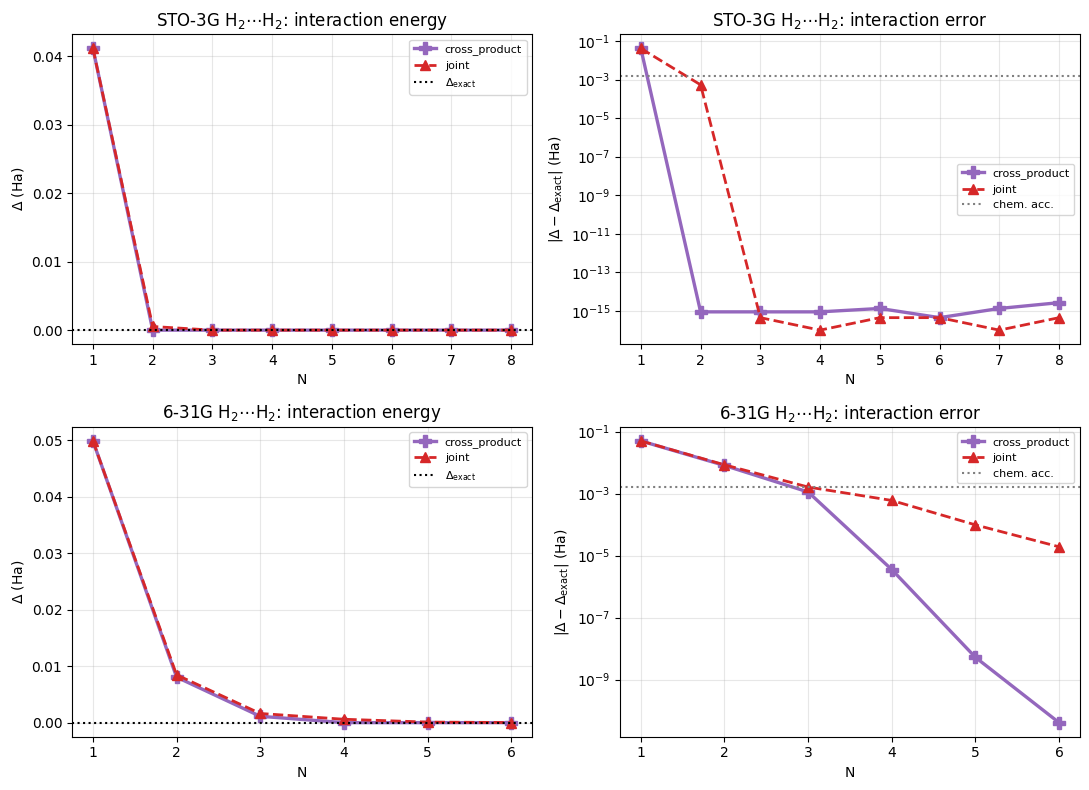

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h2_cross_product_interaction_vs_N.png


In [6]:
fig, axes = plt.subplots(len(BASIS_LIST), 2, figsize=(11, 4.0 * len(BASIS_LIST)))
if len(BASIS_LIST) == 1:
    axes = np.array([axes])
for row, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h2[df_h2h2['basis'] == basis]
    ax = axes[row, 0]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h2[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_2$: interaction energy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_2$: interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
path = os.path.join(HETERO_DIR, 'h2h2_cross_product_interaction_vs_N.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


## 9. H$_2$⋯H$_4$ interaction energies — `cross_product` vs `joint`

System: $H=H_{\mathrm{H_2}}\otimes I+I\otimes H_{\mathrm{H_4}}$.

Same exponential bases as §8 with unequal fragments.

**Left:** $\Delta(N)=E_{\mathrm{method}}(N)-E_{\mathrm{exact}}(\mathrm{H_2})-E_{\mathrm{exact}}(\mathrm{H_4})$.

**Right:** $|\Delta(N)-\Delta_{\mathrm{exact}}|$ with $\Delta_{\mathrm{exact}}=0$.


In [7]:
h2h4_rows = []
delta_exact_h2h4 = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    # Cap H2+H4 6-31G Krylov N for cost on ~50k-dim space
    if basis == '6-31g':
        N_max = min(N_max, 4)
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'§9  H2...H4  ({label})  N_max={N_max}')
    print('=' * 60)

    mono_a = build_monomer(2, basis)
    mono_b = build_monomer(4, basis)
    sys = build_kronecker_dimer(mono_a, mono_b)
    E_ref = sys['E_exact_sum']
    d_ex = sys['delta_exact']
    delta_exact_h2h4[basis] = d_ex
    print(f"  dims A/B={mono_a['dim']}/{mono_b['dim']}  dimer={sys['joint_dim']}  "
          f"sparse={sys['use_sparse']}  Delta_exact={d_ex:.3e}")

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name in VARIANTS:
            out = energy_from_states(sys, VARIANT_BUILDERS[name](sys, N))
            delta = out['gs_total'] - E_ref
            h2h4_rows.append({
                'system': 'H2+H4', 'basis': basis, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - sys['gs_total']),
                'delta': delta, 'delta_exact': d_ex,
                'err_int': abs(delta - d_ex),
            })
            print(f'{name}(err={abs(delta - d_ex):.2e})', end='  ')
        print()
        gc.collect()
    del sys, mono_a, mono_b
    gc.collect()
    print()

df_h2h4 = pd.DataFrame(h2h4_rows)
path_csv = os.path.join(HETERO_DIR, 'h2h4_cross_product_interaction_vs_N.csv')
df_h2h4.to_csv(path_csv, index=False)
print('Saved:', path_csv)


§9  H2...H4  (STO-3G)  N_max=8
  dims A/B=6/70  dimer=420  sparse=False  Delta_exact=-8.438e-15
  N=1 ... cross_product(err=6.17e-02)  joint(err=6.17e-02)  
  N=2 ... cross_product(err=8.50e-03)  joint(err=1.01e-02)  
  N=3 ... cross_product(err=2.32e-03)  joint(err=2.59e-03)  
  N=4 ... cross_product(err=6.90e-04)  joint(err=9.51e-04)  
  N=5 ... cross_product(err=2.63e-04)  joint(err=3.93e-04)  
  N=6 ... cross_product(err=6.88e-05)  joint(err=1.21e-04)  
  N=7 ... cross_product(err=2.28e-05)  joint(err=6.59e-05)  
  N=8 ... cross_product(err=1.63e-06)  joint(err=4.00e-05)  

§9  H2...H4  (6-31G)  N_max=4
  dims A/B=28/1820  dimer=50960  sparse=True  Delta_exact=-2.487e-14
  N=1 ... cross_product(err=7.80e-02)  joint(err=7.80e-02)  
  N=2 ... cross_product(err=1.33e-02)  joint(err=1.42e-02)  
  N=3 ... cross_product(err=3.68e-03)  joint(err=4.69e-03)  
  N=4 ... cross_product(err=1.38e-03)  joint(err=1.86e-03)  

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/kryl

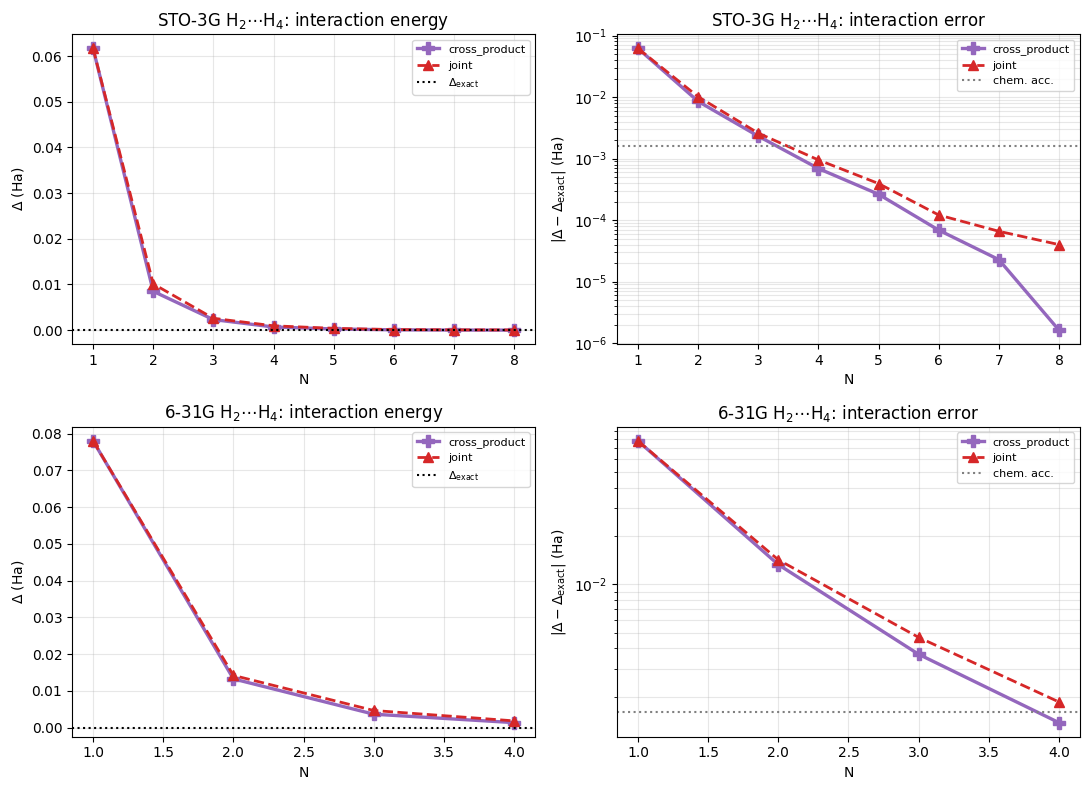

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/h2h4_cross_product_interaction_vs_N.png


In [8]:
plot_bases = [b for b in BASIS_LIST if b in delta_exact_h2h4]
fig, axes = plt.subplots(len(plot_bases), 2, figsize=(11, 4.0 * len(plot_bases)))
if len(plot_bases) == 1:
    axes = np.array([axes])
for row, basis in enumerate(plot_bases):
    label = BASIS_CONFIG[basis]['label']
    sub = df_h2h4[df_h2h4['basis'] == basis]
    ax = axes[row, 0]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['delta'], color=st['color'], marker=st['marker'],
                ls=st['ls'], lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(delta_exact_h2h4[basis], color='k', ls=':', label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_4$: interaction energy')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for name in VARIANTS:
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.semilogy(s['N'], np.maximum(s['err_int'], 1e-16),
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=st['lw'], ms=st['ms'], label=name)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chem. acc.')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ (Ha)')
    ax.set_title(rf'{label} H$_2\cdots$H$_4$: interaction error')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
path = os.path.join(HETERO_DIR, 'h2h4_cross_product_interaction_vs_N.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)


### 8b / 9b. Size consistency (non-interacting / R=1000 limit)

Monomer QKD refs use the **same** $\Delta t$ as the dimer:

$$
|\phi^{A}_{k}\rangle=e^{-i H_A k\Delta t}|\mathrm{HF}_A\rangle,\qquad
|\phi^{B}_{k}\rangle=e^{-i H_B k\Delta t}|\mathrm{HF}_B\rangle.
$$

**Left:** $|\Delta_{\mathrm{SC}}(N)|=|E_{\mathrm{method}}(N)-E_A^{\mathrm{QKD}}(N)-E_B^{\mathrm{QKD}}(N)|$.

**Right:** $|E_{\mathrm{method}}(N)-E_{\mathrm{exact}}(H)|$ with $E_{\mathrm{exact}}(H)=E_{\mathrm{exact}}(H_A)+E_{\mathrm{exact}}(H_B)$.


In [9]:
SC_BASIS_LIST = list(BASIS_LIST)
# H2...H2: sto-3g converges by N~3; H2...H4 needs N~12 for H4 QKD (dim 70).
SC_N_MAX = {'sto-3g': {'H2+H2': 8, 'H2+H4': 12}, '6-31g': {'H2+H2': 6, 'H2+H4': 4}}
SC_ASSERT = 1e-10
# Right-column exact-dimer assert only when monomer QKD has reached exact GS.
MONO_ADEQUATE = 1e-9
sc_rows = []

print('=' * 60)
print('Size consistency — Kronecker R->inf / cross_product vs joint')
print('=' * 60)

for SC_BASIS in SC_BASIS_LIST:
    label = BASIS_CONFIG[SC_BASIS]['label']
    print()
    print('*' * 60)
    print(f'Basis: {label}')
    print('*' * 60)

    print(f"H2...H2 ({label}) N_max={SC_N_MAX[SC_BASIS]['H2+H2']} ...")
    mono = build_monomer(2, SC_BASIS)
    sys_hh = build_kronecker_dimer(mono, mono)
    E_ex = sys_hh['gs_total']
    SC_DIMS = list(range(1, SC_N_MAX[SC_BASIS]['H2+H2'] + 1))
    df_qkd = sweep_mono_qkd(mono, SC_DIMS, dt=sys_hh['dt_tot'])
    print(f"  E_exact={E_ex:.10f}  mono_dim={mono['dim']}")

    for N in SC_DIMS:
        print(f'  N={N} ...', end=' ', flush=True)
        E_sum = 2.0 * float(df_qkd.loc[df_qkd['N'] == N, 'E_mono_qkd'].iloc[0])
        for name in VARIANTS:
            out = energy_from_states(sys_hh, VARIANT_BUILDERS[name](sys_hh, N))
            d_mono = out['gs_total'] - E_sum
            d_dim = out['gs_total'] - E_ex
            sc_rows.append({
                'system': 'H2+H2', 'basis': SC_BASIS, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'], 'E_exact': E_ex,
                'E_mono_sum_qkd': E_sum,
                'delta_vs_mono': d_mono, 'delta_vs_dimer1000': d_dim,
            })
            print(f'{name}(D={d_mono:+.2e})', end='  ')
        print()
        gc.collect()
    del sys_hh, mono
    gc.collect()

    N_max_h4 = SC_N_MAX[SC_BASIS]['H2+H4']
    print(f'H2...H4 ({label}) N_max={N_max_h4} ...')
    SC_DIMS_H4 = list(range(1, N_max_h4 + 1))
    ma = build_monomer(2, SC_BASIS)
    mb = build_monomer(4, SC_BASIS)
    sys_h4 = build_kronecker_dimer(ma, mb)
    E_ex = sys_h4['gs_total']
    df_a = sweep_mono_qkd(ma, SC_DIMS_H4, dt=sys_h4['dt_tot'])
    df_b = sweep_mono_qkd(mb, SC_DIMS_H4, dt=sys_h4['dt_tot'])
    print(f"  E_exact={E_ex:.10f}  dims={ma['dim']}+{mb['dim']}->{sys_h4['joint_dim']}")

    for N in SC_DIMS_H4:
        print(f'  N={N} ...', end=' ', flush=True)
        E_sum = (
            float(df_a.loc[df_a['N'] == N, 'E_mono_qkd'].iloc[0])
            + float(df_b.loc[df_b['N'] == N, 'E_mono_qkd'].iloc[0])
        )
        for name in VARIANTS:
            out = energy_from_states(sys_h4, VARIANT_BUILDERS[name](sys_h4, N))
            d_mono = out['gs_total'] - E_sum
            d_dim = out['gs_total'] - E_ex
            sc_rows.append({
                'system': 'H2+H4', 'basis': SC_BASIS, 'label': label,
                'N': N, 'variant': name,
                'raw_dim': out['raw_dim'], 'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'], 'E_exact': E_ex,
                'E_mono_sum_qkd': E_sum,
                'delta_vs_mono': d_mono, 'delta_vs_dimer1000': d_dim,
            })
            print(f'{name}(D={d_mono:+.2e})', end='  ')
        print()
        gc.collect()
    del sys_h4, ma, mb
    gc.collect()

df_sc = pd.DataFrame(sc_rows)
df_sc['abs_vs_mono'] = np.abs(df_sc['delta_vs_mono'])
df_sc['abs_vs_dimer1000'] = np.abs(df_sc['delta_vs_dimer1000'])
path_csv = os.path.join(HETERO_DIR, 'sc_R1000_cross_product.csv')
df_sc.to_csv(path_csv, index=False)
print('\nSaved:', path_csv)

print('\n=== SC at N_max ===')
for basis in SC_BASIS_LIST:
    sub_b = df_sc[df_sc['basis'] == basis]
    print(f"--- {BASIS_CONFIG[basis]['label']} ---")
    for system in ['H2+H2', 'H2+H4']:
        sub_s = sub_b[sub_b['system'] == system]
        if len(sub_s) == 0:
            continue
        N_show = int(sub_s['N'].max())
        sub = sub_s[sub_s['N'] == N_show]
        print(f'  {system} at N={N_show}:')
        print(sub[['variant', 'abs_vs_mono', 'abs_vs_dimer1000']].to_string(
            index=False, float_format=lambda x: f'{x:.4e}'))

print('\n=== SC asserts (cross_product) ===')
for basis in SC_BASIS_LIST:
    for system in ['H2+H2', 'H2+H4']:
        sub = df_sc[(df_sc['basis'] == basis) & (df_sc['system'] == system)
                    & (df_sc['variant'] == 'cross_product')]
        if len(sub) == 0:
            continue
        r = sub.loc[sub['N'].idxmax()]
        mono_gap = abs(r['E_mono_sum_qkd'] - r['E_exact'])
        print(f"{BASIS_CONFIG[basis]['label']} {system}: "
              f"|d_mono|={r['abs_vs_mono']:.3e}  |d_dim|={r['abs_vs_dimer1000']:.3e}  "
              f"mono_gap={mono_gap:.3e}")
        assert r['abs_vs_mono'] < SC_ASSERT, (
            f'{basis} {system} abs_vs_mono={r["abs_vs_mono"]}')
        if mono_gap < MONO_ADEQUATE:
            assert r['abs_vs_dimer1000'] < SC_ASSERT, (
                f'{basis} {system} abs_vs_dimer={r["abs_vs_dimer1000"]}')
        else:
            print(f'  (skip |d_dim| assert: monomer Krylov not yet adequate)')
print('SC asserts passed.')


Size consistency — Kronecker R->inf / cross_product vs joint

************************************************************
Basis: STO-3G
************************************************************
H2...H2 (STO-3G) N_max=8 ...
  E_exact=-2.2745403493  mono_dim=6
  N=1 ... cross_product(D=+0.00e+00)  joint(D=+0.00e+00)  
  N=2 ... cross_product(D=-8.88e-16)  joint(D=+5.32e-04)  
  N=3 ... cross_product(D=+0.00e+00)  joint(D=-4.44e-16)  
  N=4 ... cross_product(D=-8.88e-16)  joint(D=-1.78e-15)  
  N=5 ... cross_product(D=-2.66e-15)  joint(D=-8.88e-16)  
  N=6 ... cross_product(D=+4.44e-16)  joint(D=-4.44e-16)  
  N=7 ... cross_product(D=-1.33e-15)  joint(D=+0.00e+00)  
  N=8 ... cross_product(D=+1.78e-15)  joint(D=-4.44e-16)  
H2...H4 (STO-3G) N_max=12 ...
  E_exact=-3.2770698194  dims=6+70->420
  N=1 ... cross_product(D=+0.00e+00)  joint(D=+0.00e+00)  
  N=2 ... cross_product(D=+4.44e-16)  joint(D=+1.63e-03)  
  N=3 ... cross_product(D=+1.33e-15)  joint(D=+2.75e-04)  
  N=4 ... cross_pr

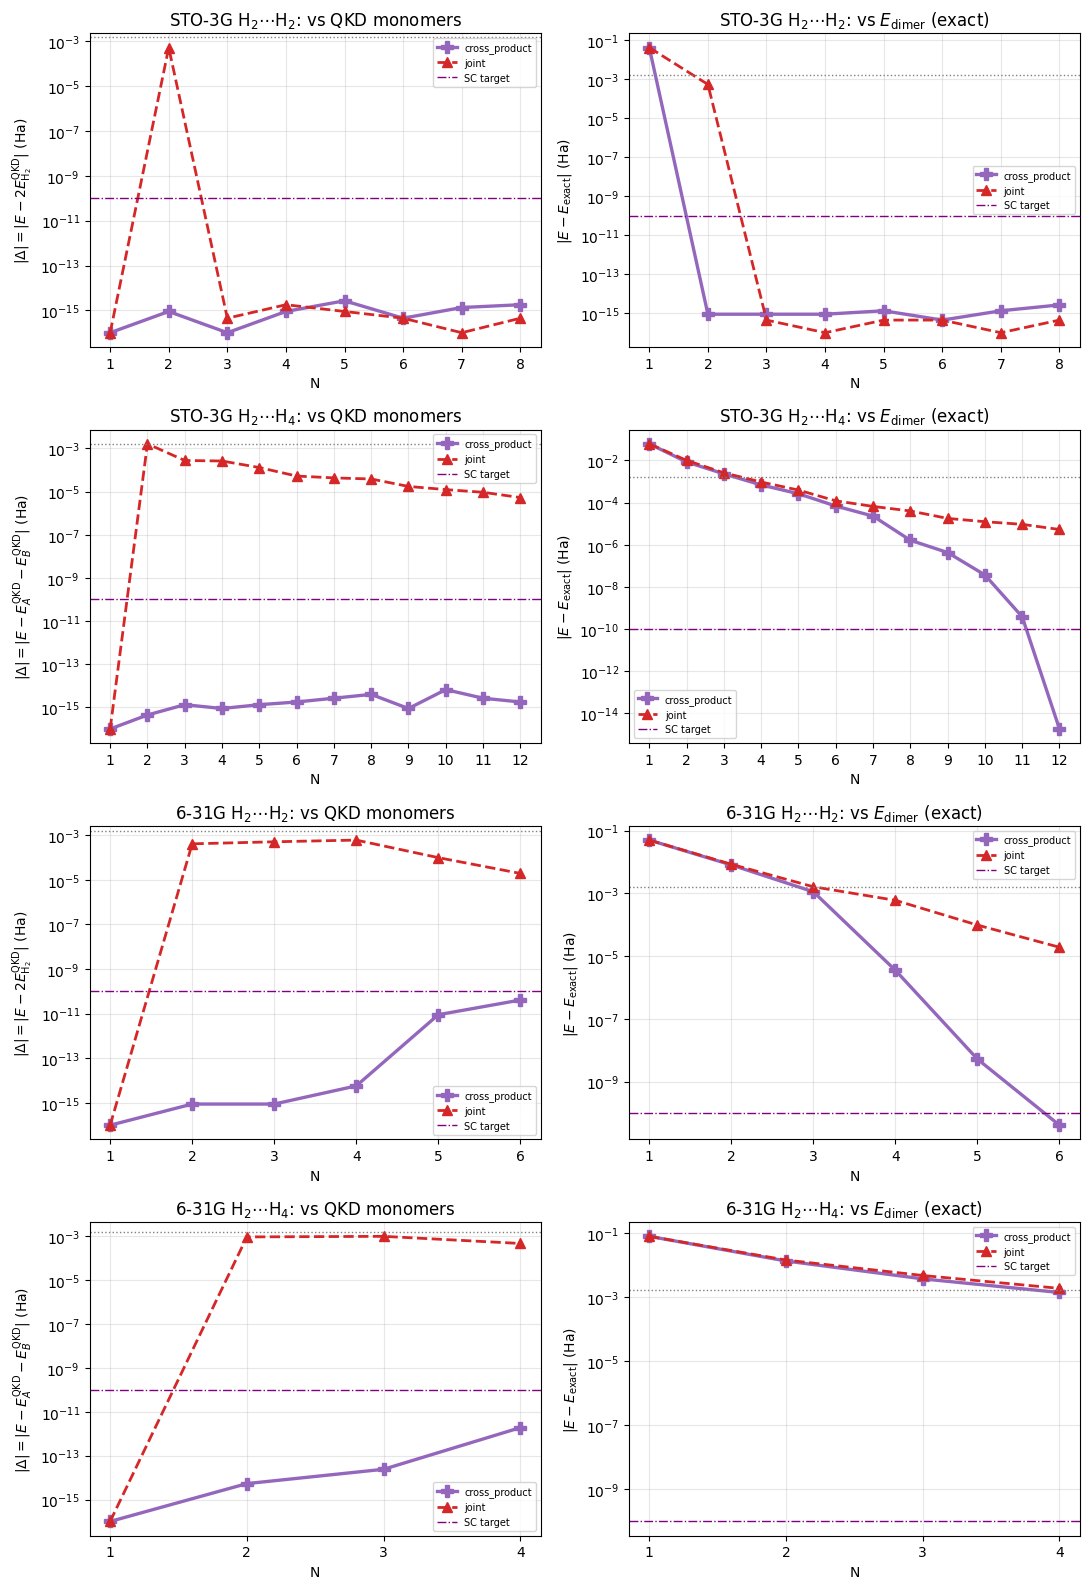

Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/hetero/sc_R1000_cross_product.png


In [10]:
n_basis = len(SC_BASIS_LIST)
fig, axes = plt.subplots(n_basis * 2, 2, figsize=(11, 4.0 * n_basis * 2))
if n_basis == 1:
    axes = np.array([axes])

panel = [
    ('H2+H2', r'H$_2\cdots$H$_2$',
     r'$|\Delta|=|E-2E_{\mathrm{H_2}}^{\mathrm{QKD}}|$'),
    ('H2+H4', r'H$_2\cdots$H$_4$',
     r'$|\Delta|=|E-E_A^{\mathrm{QKD}}-E_B^{\mathrm{QKD}}|$'),
]
for b_idx, basis in enumerate(SC_BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    for s_idx, (system, sys_label, ylab) in enumerate(panel):
        row = b_idx * 2 + s_idx
        sub_sys = df_sc[(df_sc['system'] == system) & (df_sc['basis'] == basis)]
        for col, (key, title_ref) in enumerate([
            ('abs_vs_mono', 'QKD monomers'),
            ('abs_vs_dimer1000', r'$E_{\mathrm{dimer}}$ (exact)'),
        ]):
            ax = axes[row, col]
            for name in VARIANTS:
                s = sub_sys[sub_sys['variant'] == name]
                if len(s) == 0:
                    continue
                st = VARIANT_STYLE[name]
                ax.semilogy(s['N'], np.maximum(s[key], 1e-16),
                            color=st['color'], marker=st['marker'], ls=st['ls'],
                            lw=st['lw'], ms=st['ms'], label=name)
            ax.axhline(CHEM_ACC, color='gray', ls=':', lw=1)
            ax.axhline(SC_ASSERT, color='purple', ls='-.', lw=1, label='SC target')
            ax.set_xlabel('N')
            ax.set_ylabel((ylab if col == 0 else r'$|E-E_{\mathrm{exact}}|$') + ' (Ha)')
            ax.set_title(rf'{label} {sys_label}: vs {title_ref}')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3, which='both')
            if len(sub_sys):
                ax.set_xticks(sorted(sub_sys['N'].unique()))
fig.tight_layout()
path = os.path.join(HETERO_DIR, 'sc_R1000_cross_product.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', path)
